# Lab Report 01 - Running Code

This notebook contains the full runnable practical for Lab Report 01 with explanatory comments in the code cells.

In [30]:
# Import the libraries used in this practical.
# cv2 is used for image processing operations.
# numpy is used for numerical calculations.
# matplotlib is used for displaying images and plotting histograms.
# pathlib is used to safely find the image file.
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set a default figure size so plots appear clearly.
plt.rcParams["figure.figsize"] = (10, 6)

In [31]:
# Search for Girl.jpg in likely working locations.
# This allows the notebook to run from either the project root or the lab folder.
candidate_paths = [
    Path("Girl.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

# Pick the first path that exists.
image_path = next((path for path in candidate_paths if path.exists()), None)

# Stop with a clear error if the image file is missing.
if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg'. Keep it in the project root or current working directory."
    )

# Read the image using OpenCV.
# OpenCV reads color images in BGR format by default.
image_bgr = cv2.imread(str(image_path))

# If OpenCV cannot read the file, stop before continuing.
if image_bgr is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print(f"Loaded image from: {image_path.resolve()}")
print(f"BGR image shape: {image_bgr.shape}")

Loaded image from: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
BGR image shape: (512, 512, 3)


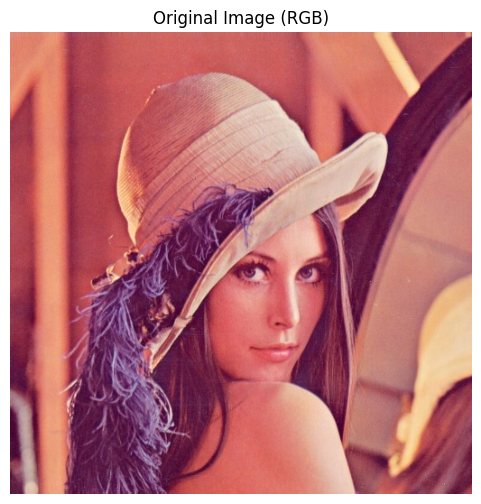

In [32]:
# Convert the image from BGR to RGB.
# This is required because matplotlib expects RGB channel order.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the correctly converted RGB image.
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

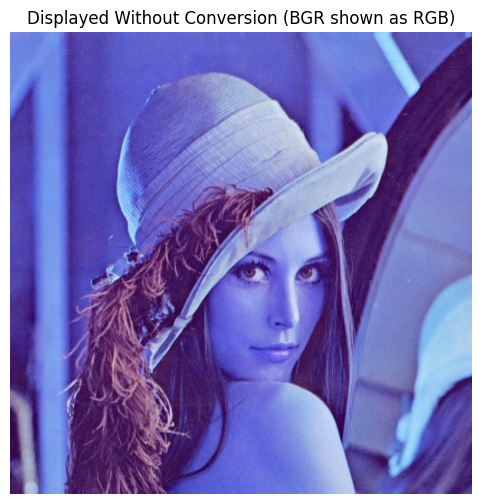

In [33]:
# Display the original BGR image directly.
# The colors appear incorrect here because it was not converted to RGB.
plt.figure(figsize=(6, 6))
plt.imshow(image_bgr)
plt.title("Displayed Without Conversion (BGR shown as RGB)")
plt.axis("off")
plt.show()

In [34]:
# Print the image shape.
# Shape format is: (height, width, channels)
print("Original RGB Image Shape:", image_rgb.shape)
print("Height:", image_rgb.shape[0])
print("Width :", image_rgb.shape[1])
print("Channels:", image_rgb.shape[2])

Original RGB Image Shape: (512, 512, 3)
Height: 512
Width : 512
Channels: 3


In [35]:
# Split the RGB image into three separate channels.
# Each channel becomes a 2D array of intensity values.
r_channel, g_channel, b_channel = cv2.split(image_rgb)

print("Red Channel Shape  :", r_channel.shape)
print("Green Channel Shape:", g_channel.shape)
print("Blue Channel Shape :", b_channel.shape)

Red Channel Shape  : (512, 512)
Green Channel Shape: (512, 512)
Blue Channel Shape : (512, 512)


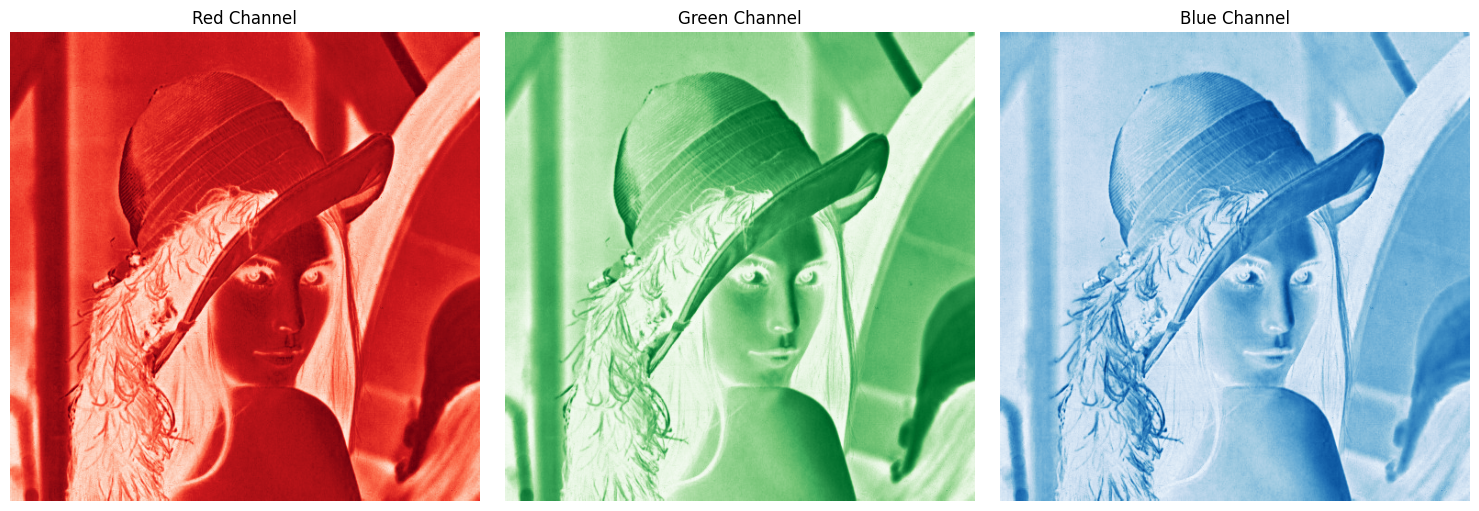

In [36]:
# Show the red, green, and blue channels separately.
# Matching colormaps make each channel easier to interpret visually.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(r_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(g_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

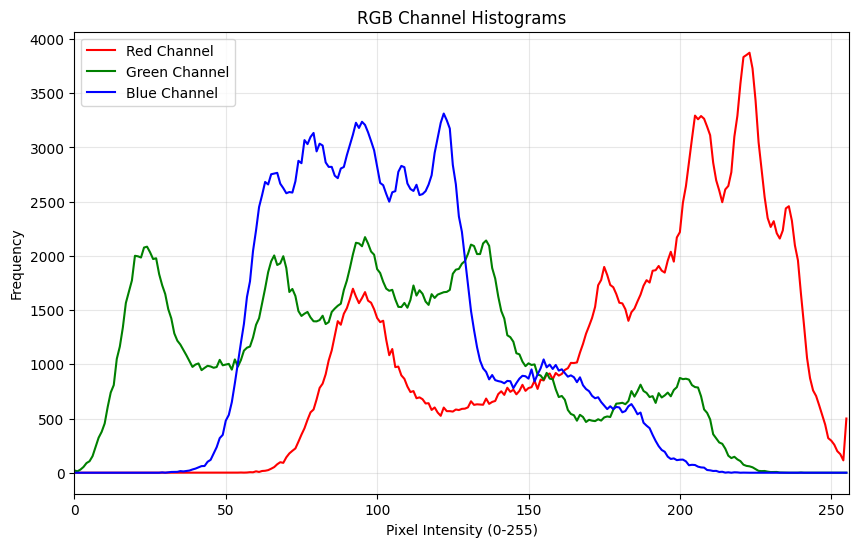

In [37]:
# Define plot colors and channel names.
colors = ("r", "g", "b")
channel_names = ["Red", "Green", "Blue"]

# Calculate and plot histograms directly from the RGB image.
# Channel indices are 0 for Red, 1 for Green, and 2 for Blue.
plt.figure(figsize=(10, 6))

for i, color in enumerate(colors):
    # Create a histogram with 256 bins for intensity values 0 to 255.
    hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f"{channel_names[i]} Channel")

plt.title("RGB Channel Histograms")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

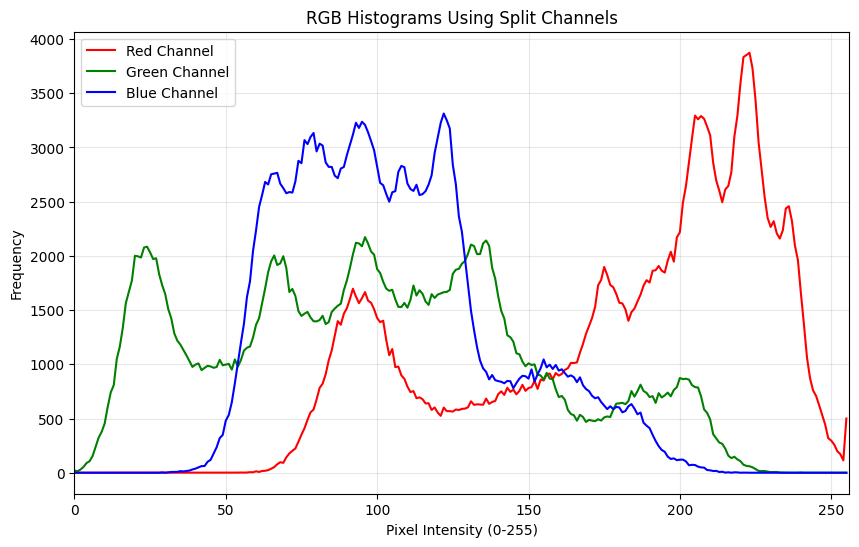

In [38]:
# Calculate histograms from the already separated channels.
# Because each channel is now a single-channel image, the channel index is 0.
hist_r = cv2.calcHist([r_channel], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([g_channel], [0], None, [256], [0, 256])
hist_b = cv2.calcHist([b_channel], [0], None, [256], [0, 256])

# Plot the separated channel histograms together.
plt.figure(figsize=(10, 6))
plt.plot(hist_r, color="r", label="Red Channel")
plt.plot(hist_g, color="g", label="Green Channel")
plt.plot(hist_b, color="b", label="Blue Channel")
plt.title("RGB Histograms Using Split Channels")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
# Compute mean intensity and standard deviation from raw pixel values.
# Mean gives average brightness.
# Standard deviation shows how much the values vary.
red_mean = np.mean(r_channel)
green_mean = np.mean(g_channel)
blue_mean = np.mean(b_channel)

red_std = np.std(r_channel)
green_std = np.std(g_channel)
blue_std = np.std(b_channel)

print("Channel Statistics Using Direct Pixel Values")
print("-" * 48)
print(f"Red Channel   -> Mean: {red_mean:.2f}, Standard Deviation: {red_std:.2f}")
print(f"Green Channel -> Mean: {green_mean:.2f}, Standard Deviation: {green_std:.2f}")
print(f"Blue Channel  -> Mean: {blue_mean:.2f}, Standard Deviation: {blue_std:.2f}")

Channel Statistics Using Direct Pixel Values
------------------------------------------------
Red Channel   -> Mean: 179.74, Standard Deviation: 49.08
Green Channel -> Mean: 99.56, Standard Deviation: 52.73
Blue Channel  -> Mean: 105.38, Standard Deviation: 33.89


In [40]:
# Peak intensity is the intensity value that occurs most frequently.
# np.argmax returns the index of the highest histogram count.
red_peak = int(np.argmax(hist_r))
green_peak = int(np.argmax(hist_g))
blue_peak = int(np.argmax(hist_b))

print("Peak Intensity Values")
print("-" * 24)
print(f"Red Channel Peak Intensity   : {red_peak}")
print(f"Green Channel Peak Intensity : {green_peak}")
print(f"Blue Channel Peak Intensity  : {blue_peak}")

Peak Intensity Values
------------------------
Red Channel Peak Intensity   : 223
Green Channel Peak Intensity : 96
Blue Channel Peak Intensity  : 122


In [41]:
# Define a reusable function to analyze one color channel.
# The function returns mean, standard deviation, and peak intensity.
def channel_stats(channel, name):
    # Average intensity of the channel.
    mean_value = np.mean(channel)

    # Spread of intensity values around the mean.
    std_value = np.std(channel)

    # Histogram helps find the most frequent intensity value.
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    peak_value = int(np.argmax(hist))

    print(f"{name} Channel")
    print(f"Mean Intensity     : {mean_value:.2f}")
    print(f"Standard Deviation : {std_value:.2f}")
    print(f"Peak Intensity     : {peak_value}")
    print()

    return mean_value, std_value, peak_value

In [42]:
# Run the channel analysis function for red, green, and blue channels.
print("Detailed Channel Analysis")
print("=" * 26)

red_stats = channel_stats(r_channel, "Red")
green_stats = channel_stats(g_channel, "Green")
blue_stats = channel_stats(b_channel, "Blue")

Detailed Channel Analysis
Red Channel
Mean Intensity     : 179.74
Standard Deviation : 49.08
Peak Intensity     : 223

Green Channel
Mean Intensity     : 99.56
Standard Deviation : 52.73
Peak Intensity     : 96

Blue Channel
Mean Intensity     : 105.38
Standard Deviation : 33.89
Peak Intensity     : 122



In [43]:
# Compute statistics again using histogram weights.
# This is an advanced method and should match the direct calculations closely.
print("Histogram-Based Statistical Analysis")
print("=" * 36)

for i, name in enumerate(channel_names):
    # Flatten the histogram from shape (256, 1) to (256,).
    hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256]).flatten()

    # Intensity values range from 0 to 255.
    intensity_values = np.arange(256)

    # Weighted mean intensity.
    mean_intensity = np.average(intensity_values, weights=hist)

    # Weighted standard deviation.
    std_intensity = np.sqrt(
        np.average((intensity_values - mean_intensity) ** 2, weights=hist)
    )

    # Most common intensity value in the histogram.
    peak_intensity = int(np.argmax(hist))

    print(f"{name} Channel")
    print(f"Mean Intensity     : {mean_intensity:.2f}")
    print(f"Standard Deviation : {std_intensity:.2f}")
    print(f"Peak Intensity     : {peak_intensity}")
    print()

Histogram-Based Statistical Analysis
Red Channel
Mean Intensity     : 179.74
Standard Deviation : 49.08
Peak Intensity     : 223

Green Channel
Mean Intensity     : 99.56
Standard Deviation : 52.73
Peak Intensity     : 96

Blue Channel
Mean Intensity     : 105.38
Standard Deviation : 33.89
Peak Intensity     : 122



In [44]:
# Final conclusion message for the practical.
print("Lab Completed Successfully.")
print("The image was loaded, converted from BGR to RGB,")
print("displayed correctly, split into RGB channels,")
print("analyzed using histograms, and evaluated using")
print("mean, standard deviation, and peak intensity.")

Lab Completed Successfully.
The image was loaded, converted from BGR to RGB,
displayed correctly, split into RGB channels,
analyzed using histograms, and evaluated using
mean, standard deviation, and peak intensity.
